In [3]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 5.1 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.4 MB/s  0:00:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE, ADASYN
import xgboost as xgb
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/creditcard_processed.csv')
feature_cols = [c for c in df.columns
                if c not in ['Class','TimeOfDay','Amount_bucket']]
X = df[feature_cols]
y = df['Class']

# Stratified split
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # Upsample fraud to 10%
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Fraud: {(y_sm==1).sum()}, Legit: {(y_sm==0).sum()}")

After SMOTE - Fraud: 22745, Legit: 227451


Training Logistic Regression...
  ROC-AUC=0.9705 | Avg Precision=0.7275
Training Decision Tree...
  ROC-AUC=0.8852 | Avg Precision=0.4379
Training Random Forest...
  ROC-AUC=0.9679 | Avg Precision=0.8692
Training XGBoost...
  ROC-AUC=0.9825 | Avg Precision=0.8437
Training LightGBM...
  ROC-AUC=0.9498 | Avg Precision=0.7885


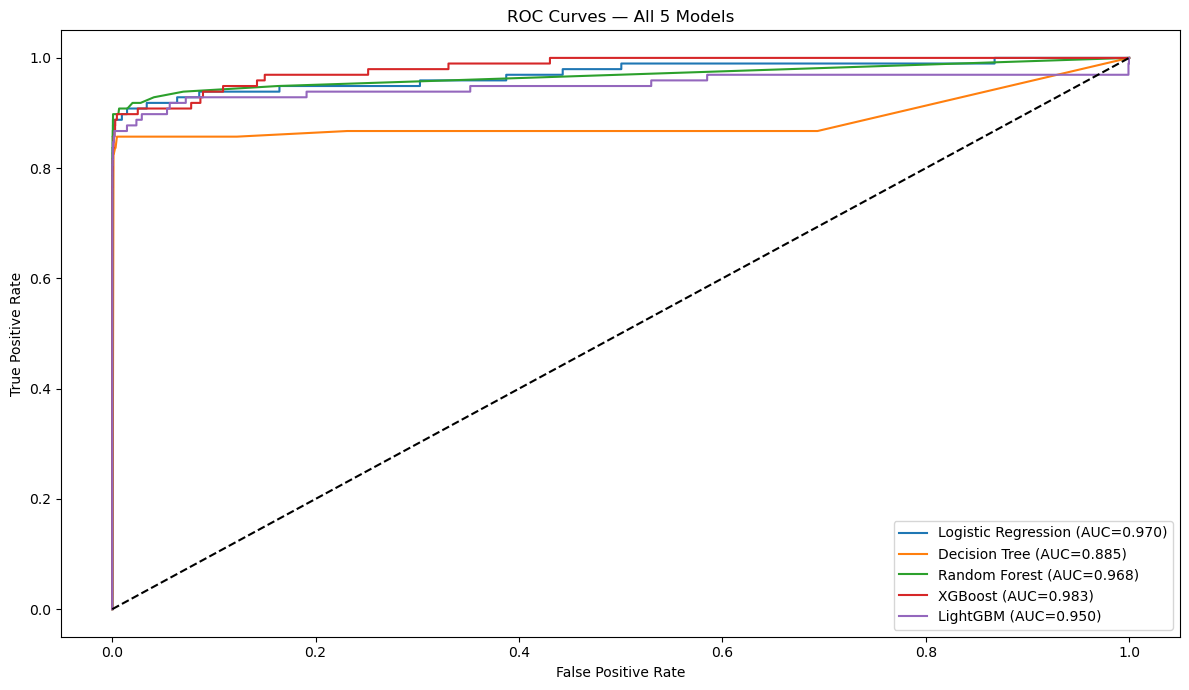

In [6]:
# Class weight ratio for XGBoost/LightGBM
import lightgbm as lgb
scale_pos = (y_train==0).sum() / (y_train==1).sum()

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',
                                                   max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=10, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200,
                                                    class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'XGBoost':              xgb.XGBClassifier(scale_pos_weight=scale_pos,
                                               n_estimators=300, learning_rate=0.05,
                                               max_depth=6, eval_metric='aucpr',
                                               random_state=42),
    'LightGBM':             lgb.LGBMClassifier(scale_pos_weight=scale_pos,
                                                 n_estimators=300, learning_rate=0.05,
                                                 random_state=42, verbosity=-1)
}

results = {}
plt.figure(figsize=(12,7))

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_sm, y_sm)
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)

    results[name] = {
        'model': model, 'probs': y_prob,
        'ROC-AUC': round(auc,4), 'Avg Precision': round(ap,4)
    }

    fpr,tpr,_ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    print(f"  ROC-AUC={auc:.4f} | Avg Precision={ap:.4f}")

plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curves — All 5 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

In [7]:
# For fraud detection, we want high Recall (catch most fraud)
# Default threshold = 0.5 may miss many fraud cases
# We tune threshold on Precision-Recall curve

xgb_probs = results['XGBoost']['probs']
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

# Find threshold that maximizes F1-Score
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
             precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

print(f"Default threshold (0.5):")
default_pred = (xgb_probs >= 0.5).astype(int)
print(classification_report(y_test, default_pred,
      target_names=['Legit','Fraud']))

print(f"\nOptimized threshold ({best_thresh:.3f}):")
optimized_pred = (xgb_probs >= best_thresh).astype(int)
print(classification_report(y_test, optimized_pred,
      target_names=['Legit','Fraud']))

# Save predictions with fraud probability score (0-100)
output = X_test.copy()
output['Actual_Fraud']       = y_test.values
output['Fraud_Probability']  = (xgb_probs * 100).round(2)
output['Predicted_Fraud']    = optimized_pred
output['Risk_Level'] = pd.cut(
    xgb_probs, bins=[0,0.3,0.6,0.85,1.0],
    labels=['Low','Medium','High','Critical'])
output.to_csv('../data/predictions/fraud_predictions.csv', index=False)
print("✅ Fraud predictions saved with risk levels")

Default threshold (0.5):
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.28      0.89      0.42        98

    accuracy                           1.00     56962
   macro avg       0.64      0.94      0.71     56962
weighted avg       1.00      1.00      1.00     56962


Optimized threshold (1.000):
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.77      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

✅ Fraud predictions saved with risk levels


In [8]:
!pip install shap

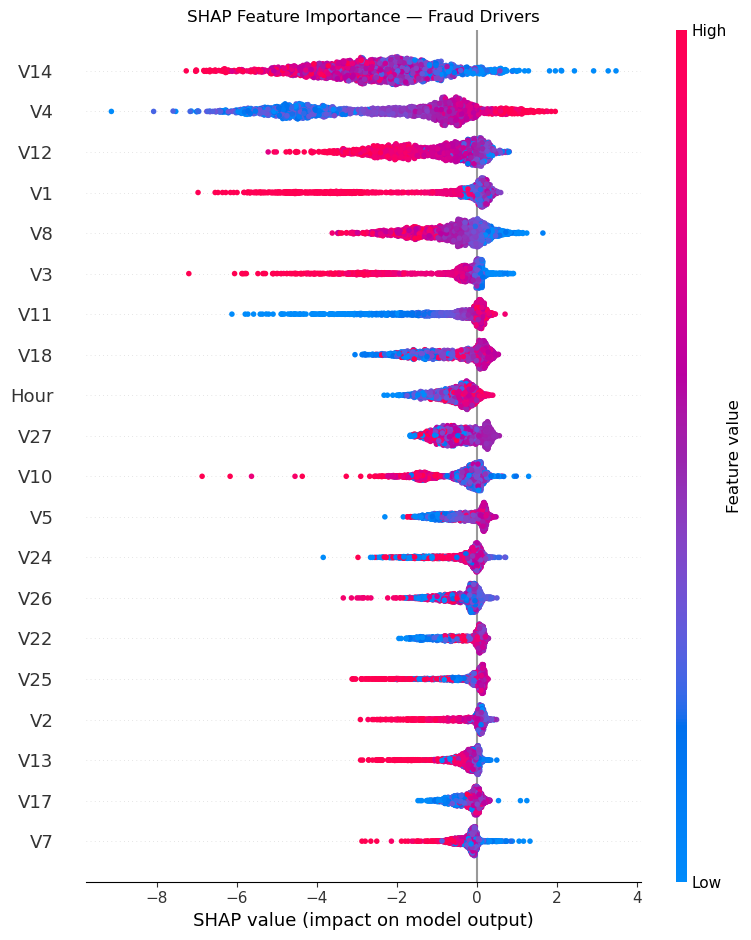

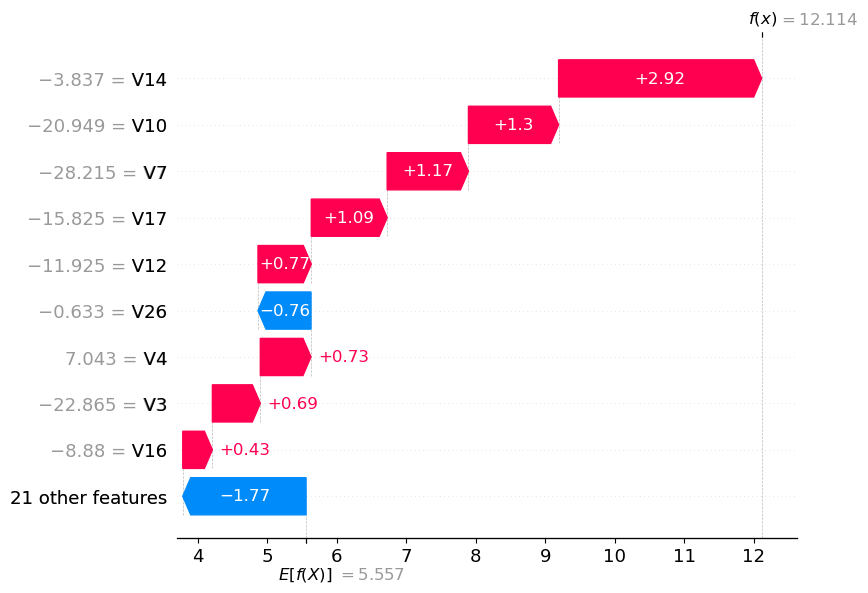

✅ SHAP explainability plots saved!


In [9]:
import shap
import xgboost as xgb

# Use a sample for SHAP (full dataset is slow)
X_sample = X_test.sample(2000, random_state=42)

# Get the best XGBoost model
best_model = results['XGBoost']['model']

# Create SHAP explainer
explainer    = shap.TreeExplainer(best_model)
shap_values  = explainer.shap_values(X_sample)

# 1. Summary Plot — which features drive fraud most
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance — Fraud Drivers')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Explain ONE fraud transaction (waterfall plot)
# Find first actual fraud in sample
fraud_idx = y_test.loc[X_sample.index]
fraud_sample_idx = fraud_idx[fraud_idx==1].index[0]
pos_in_sample = X_sample.index.get_loc(fraud_sample_idx)

shap.plots.waterfall(explainer(X_sample)[pos_in_sample])
print("✅ SHAP explainability plots saved!")